<a href="https://colab.research.google.com/github/MeFabiLuz/Marketing_Analitics/blob/main/Teste_A_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1.Importação e visão geral

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ab_test_criativos_marketing.csv")




In [4]:
df.head()


,data,grupo,criativo,impressoes,cliques,conversoes,custo,receita,ctr,taxa_conversao,cpc,roas
0,2025-01-01,A,Produto_Fundo_Branco,8175,132,2,59.77,143.47,0.016147,0.015152,0.452803,2.400368
1,2025-01-01,B,Modelo_Usando_Produto,10602,222,5,96.17,440.96,0.020939,0.022523,0.433198,4.585214
2,2025-01-02,A,Produto_Fundo_Branco,11116,169,2,96.37,146.96,0.015203,0.011834,0.570237,1.524956
3,2025-01-02,B,Modelo_Usando_Produto,10598,277,8,142.25,638.52,0.026137,0.028881,0.513538,4.488717
4,2025-01-03,A,Produto_Fundo_Branco,10652,269,9,117.26,655.69,0.025253,0.033457,0.435911,5.591762


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            60 non-null     object 
 1   grupo           60 non-null     object 
 2   criativo        60 non-null     object 
 3   impressoes      60 non-null     int64  
 4   cliques         60 non-null     int64  
 5   conversoes      60 non-null     int64  
 6   custo           60 non-null     float64
 7   receita         60 non-null     float64
 8   ctr             60 non-null     float64
 9   taxa_conversao  60 non-null     float64
 10  cpc             60 non-null     float64
 11  roas            60 non-null     float64
dtypes: float64(6), int64(3), object(3)
memory usage: 5.8+ KB


In [6]:
df.describe()

,impressoes,cliques,conversoes,custo,receita,ctr,taxa_conversao,cpc,roas
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,10233.216667,216.200000,5.050000,109.813500,410.412667,0.021165,0.022763,0.508116,3.686490
std,1128.197544,42.196393,2.982577,25.341701,249.835928,0.003637,0.011503,0.064680,1.988390
min,8090.000000,132.000000,0.000000,59.770000,0.000000,0.014416,0.000000,0.401250,0.000000
25%,9332.500000,178.000000,3.000000,92.875000,232.957500,0.018496,0.014788,0.442599,2.321296
50%,10469.500000,218.500000,5.000000,107.415000,372.235000,0.021213,0.021247,0.511991,3.308409
75%,11237.000000,246.500000,7.000000,129.717500,550.592500,0.023813,0.029345,0.564595,4.530161
max,11980.000000,325.000000,13.000000,166.310000,1137.940000,0.029114,0.048980,0.617113,8.994828


##2.Resumo por grupo (A vs B)

In [7]:
resumo = df.groupby("grupo").agg(
    impressoes=("impressoes", "sum"),
    cliques=("cliques", "sum"),
    conversoes=("conversoes", "sum"),
    custo=("custo", "sum"),
    receita=("receita", "sum")
).reset_index()

resumo["ctr"] = resumo["cliques"] / resumo["impressoes"]
resumo["taxa_conversao"] = resumo["conversoes"] / resumo["cliques"]
resumo["cpc"] = resumo["custo"] / resumo["cliques"]
resumo["roas"] = resumo["receita"] / resumo["custo"]

resumo


,grupo,impressoes,cliques,conversoes,custo,receita,ctr,taxa_conversao,cpc,roas
0,A,310545,6117,120,3048.86,9512.77,0.019698,0.019617,0.498424,3.120107
1,B,303448,6855,183,3539.95,15111.99,0.022590,0.026696,0.516404,4.268984


##3.Visualização básica

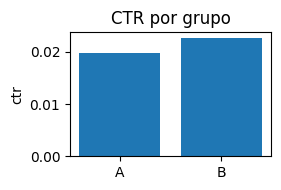

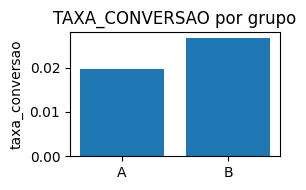

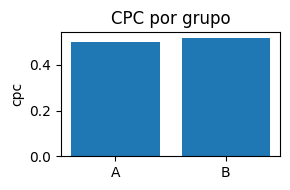

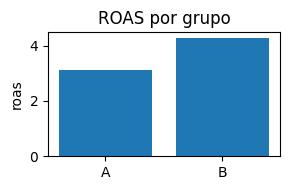

In [10]:
metricas_plot = ["ctr", "taxa_conversao", "cpc", "roas"]

for m in metricas_plot:
    plt.figure(figsize=(3,2))
    plt.bar(resumo["grupo"], resumo[m])
    plt.title(m.upper() + " por grupo")
    plt.ylabel(m)
    plt.tight_layout()
    plt.show()


##4.Teste estatístico

In [11]:
#Vamos testar se a taxa de conversão do grupo B é estatisticamente maior que a do grupo A, usando teste z para duas proporções.

# Totais
linha_a = resumo[resumo["grupo"] == "A"].iloc[0]
linha_b = resumo[resumo["grupo"] == "B"].iloc[0]

conv_a = linha_a["conversoes"]
conv_b = linha_b["conversoes"]
clicks_a = linha_a["cliques"]
clicks_b = linha_b["cliques"]

conv_a, conv_b, clicks_a, clicks_b


(np.int64(120), np.int64(183), np.int64(6117), np.int64(6855))

In [12]:
from math import sqrt
from scipy.stats import norm

# Proporções
p_a = conv_a / clicks_a
p_b = conv_b / clicks_b

# Proporção combinada (p pooled)
p_pool = (conv_a + conv_b) / (clicks_a + clicks_b)

# Estatística Z
z = (p_b - p_a) / sqrt(p_pool * (1 - p_pool) * (1/clicks_a + 1/clicks_b))

# p-value (teste unilateral: H1 = B > A)
p_value = 1 - norm.cdf(z)

p_a, p_b, z, p_value


(np.float64(0.0196174595389897),
 np.float64(0.026695842450765863),
 np.float64(2.6645140216134884),
 np.float64(0.003854982606609658))

##5.Conclusão

In [13]:
alpha = 0.05
print(f"Taxa de conversão A: {p_a:.4%}")
print(f"Taxa de conversão B: {p_b:.4%}")
print(f"Z = {z:.3f}")
print(f"p-value = {p_value:.4f}")

if p_value < alpha:
    print("Conclusão: rejeitamos H0. O criativo B performa melhor em conversão com significância estatística.")
else:
    print("Conclusão: não rejeitamos H0. A diferença entre A e B não é estatisticamente significativa.")


Taxa de conversão A: 1.9617%
Taxa de conversão B: 2.6696%
Z = 2.665
p-value = 0.0039
Conclusão: rejeitamos H0. O criativo B performa melhor em conversão com significância estatística.
